In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/student_data.csv")
df.head()

,student_id,student_name,gender,age,study_hours,attendance,previous_score,assignments,internal_marks,sleep_hours,internet_usage,extra_activities,parent_education,family_income,final_score
0,1,Aarav Trivedi,Male,22,6.3,96,83,85,73,5.5,2.2,No,Graduate,Low,39.8
1,2,Krishna Trivedi,Female,22,4.4,73,59,89,39,7.3,6.0,No,Graduate,Medium,30.2
2,3,Ishaan Desai,Male,22,9.7,71,75,83,99,8.7,5.7,No,School,Medium,42.1
3,4,Shaurya Desai,Male,22,8.6,54,48,98,47,8.4,7.8,No,Graduate,High,34.2
4,5,Vivaan Patel,Male,21,8.5,82,77,82,87,7.8,6.3,Yes,Graduate,Low,41.2


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        450 non-null    int64  
 1   student_name      450 non-null    object 
 2   gender            450 non-null    object 
 3   age               450 non-null    int64  
 4   study_hours       450 non-null    float64
 5   attendance        450 non-null    int64  
 6   previous_score    450 non-null    int64  
 7   assignments       450 non-null    int64  
 8   internal_marks    450 non-null    int64  
 9   sleep_hours       450 non-null    float64
 10  internet_usage    450 non-null    float64
 11  extra_activities  450 non-null    object 
 12  parent_education  450 non-null    object 
 13  family_income     450 non-null    object 
 14  final_score       450 non-null    float64
dtypes: float64(4), int64(6), object(5)
memory usage: 52.9+ KB


,student_id,age,study_hours,attendance,previous_score,assignments,internal_marks,sleep_hours,internet_usage,final_score
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,225.500000,19.513333,5.292222,74.980000,67.044444,67.935556,66.066667,6.482222,4.520222,32.413778
std,130.048068,1.701840,2.551554,14.158884,16.099158,17.186073,18.801151,1.441647,2.050947,4.917519
min,1.000000,17.000000,1.000000,50.000000,40.000000,40.000000,35.000000,4.000000,1.000000,20.600000
25%,113.250000,18.000000,3.025000,63.000000,52.250000,53.000000,50.000000,5.400000,2.825000,29.100000
50%,225.500000,20.000000,5.200000,75.000000,67.000000,67.000000,65.000000,6.500000,4.500000,32.100000
75%,337.750000,21.000000,7.475000,87.000000,81.000000,82.000000,82.000000,7.700000,6.300000,35.900000
max,450.000000,22.000000,10.000000,99.000000,94.000000,99.000000,99.000000,9.000000,8.000000,45.400000


In [5]:
df.isnull().sum()

student_id          0
student_name        0
gender              0
age                 0
study_hours         0
attendance          0
previous_score      0
assignments         0
internal_marks      0
sleep_hours         0
internet_usage      0
extra_activities    0
parent_education    0
family_income       0
final_score         0
dtype: int64

In [6]:
#Handle Missing Values
#Numeric columns -> fill with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [7]:
#Categorical columns → fill with mode
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

In [8]:
#Remove Duplicate Rows
df.duplicated().sum()
df = df.drop_duplicates()

In [9]:
#Fix Data Types (if needed)
df.dtypes

student_id            int64
student_name         object
gender               object
age                   int64
study_hours         float64
attendance            int64
previous_score        int64
assignments           int64
internal_marks        int64
sleep_hours         float64
internet_usage      float64
extra_activities     object
parent_education     object
family_income        object
final_score         float64
dtype: object

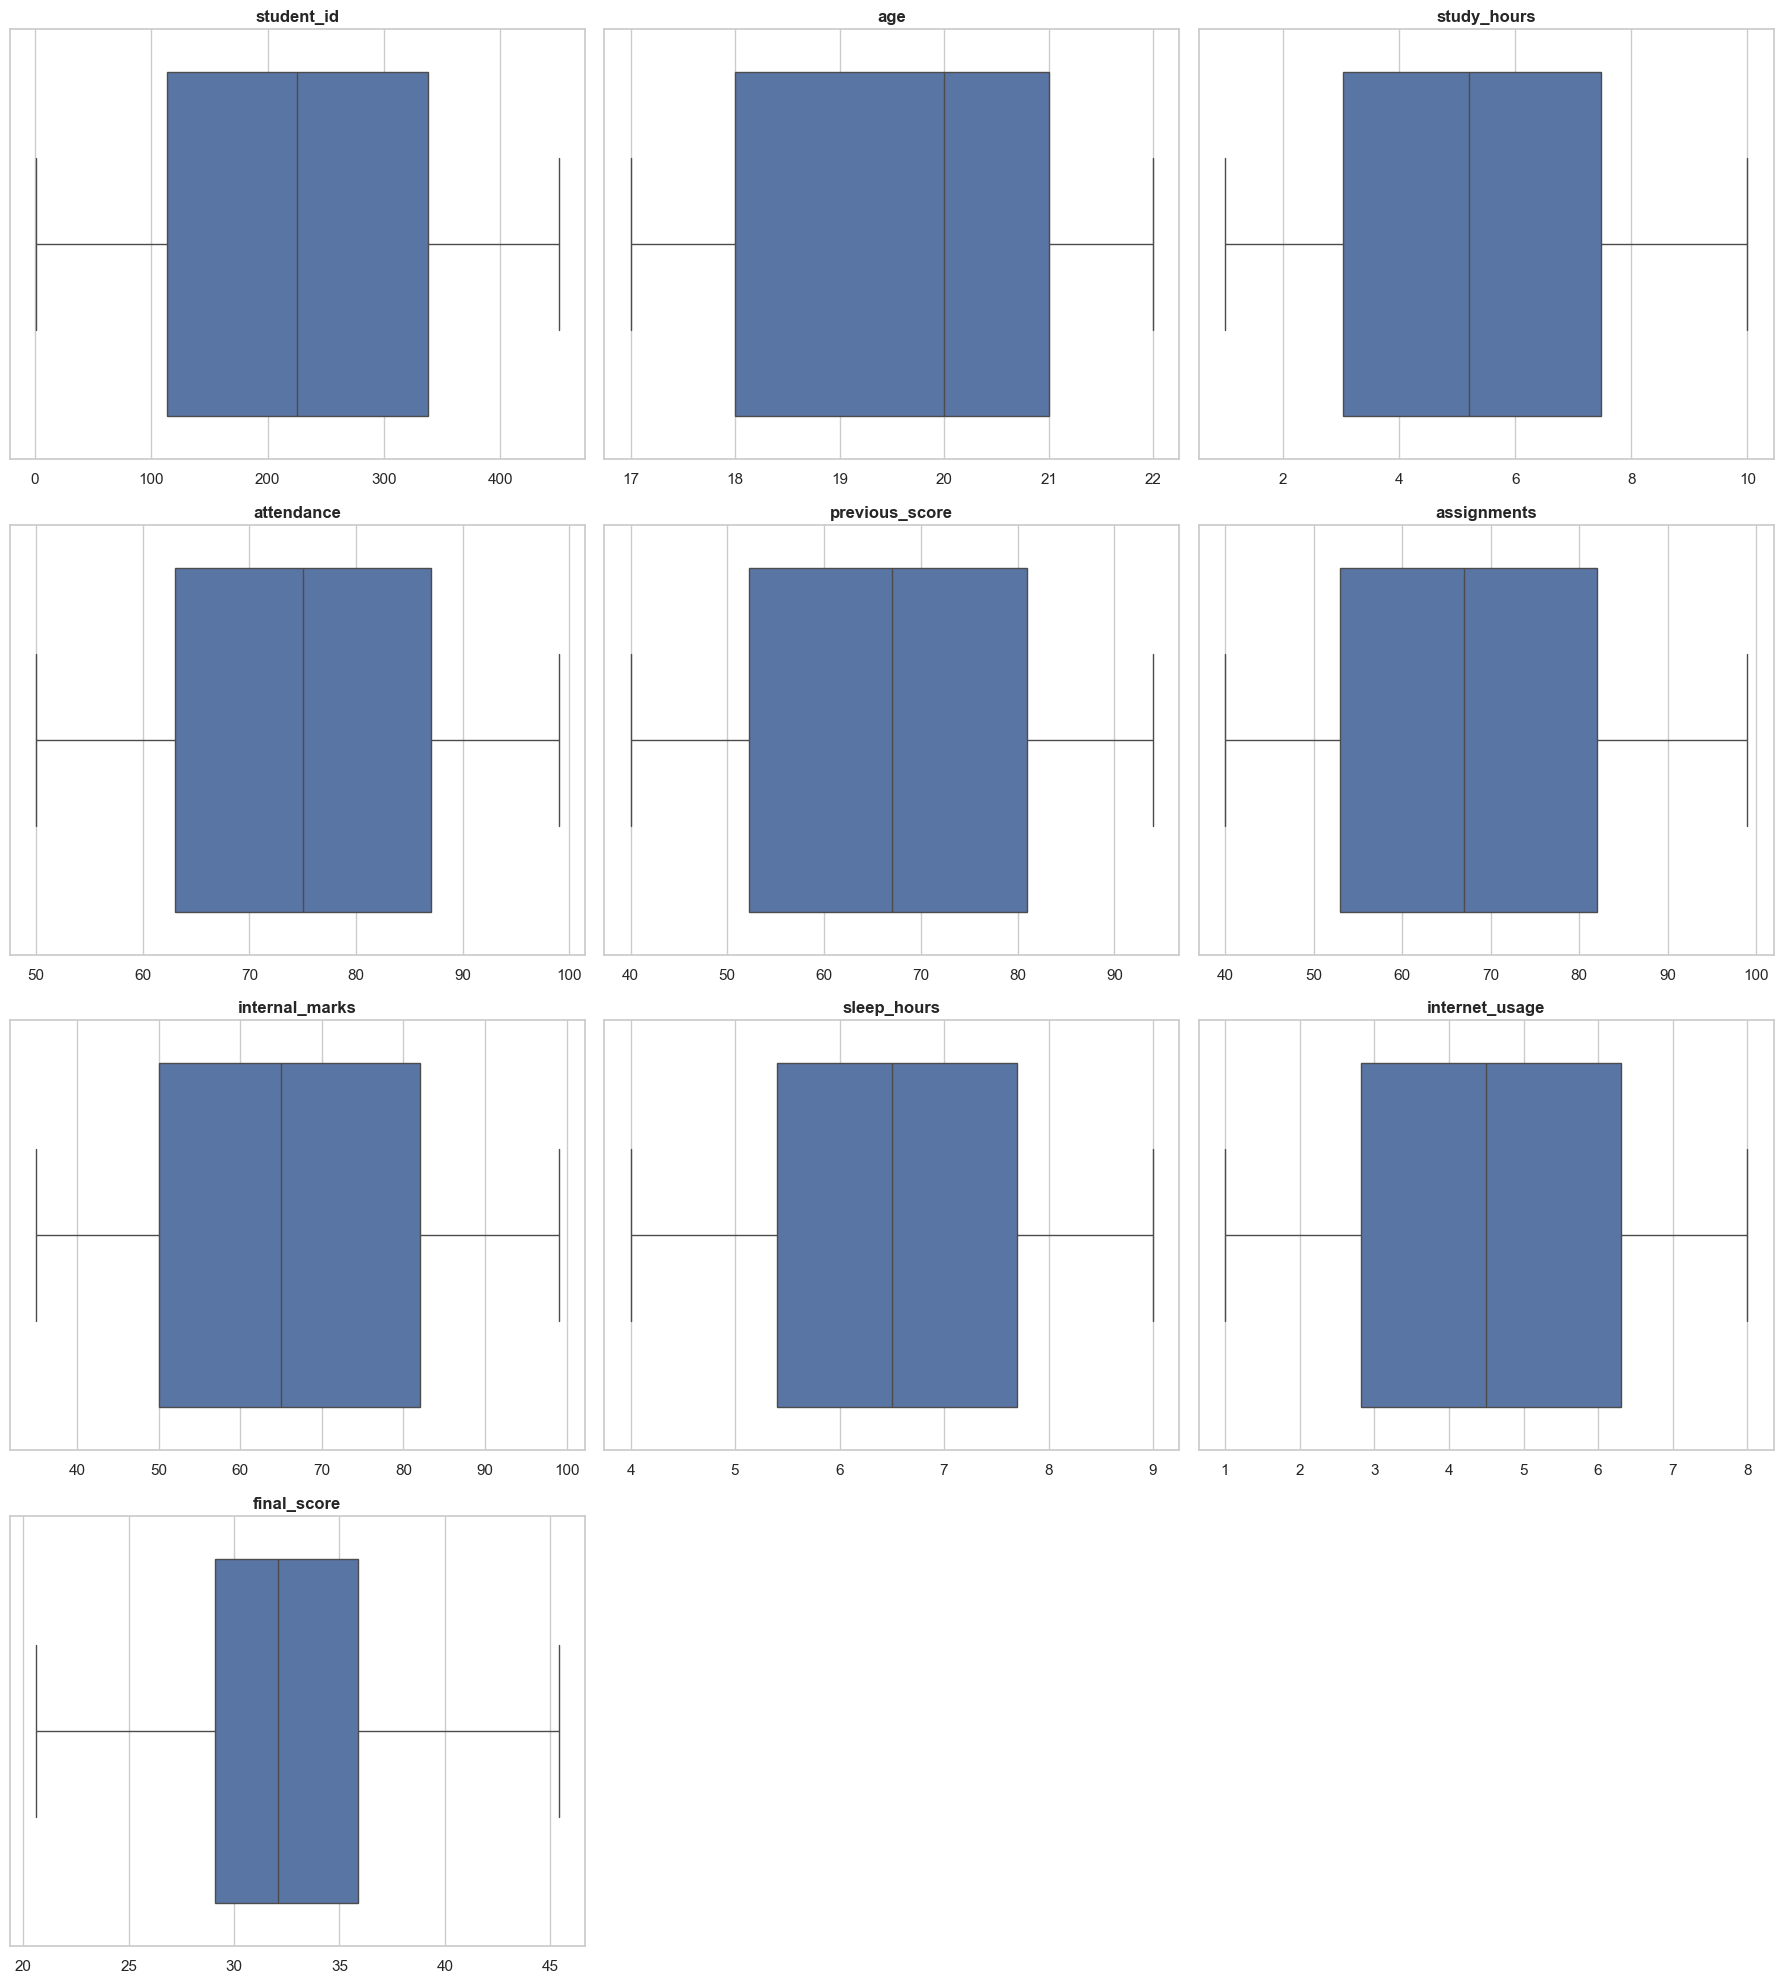

In [10]:
#Handle Outliers
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Style set (professional look)
sns.set(style="whitegrid")

# Number of columns
num_cols = df.select_dtypes(include='number').columns

# Subplot grid size
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

# Create figure
plt.figure(figsize=(18, 5 * n_rows))

# Loop through columns
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(f"{col}", fontsize=12, fontweight='bold')
    plt.xlabel("")
    
# Adjust layout
plt.tight_layout()
plt.show()

In [11]:
#Remove extreme outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [12]:
# Save original (for later use)
df_original = df.copy()

# Drop unwanted columns BEFORE encoding
df = df.drop(columns=['student_id', 'student_name'], errors='ignore')

In [13]:
#Encode Categorical Data
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)